In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/krrish1008/mmrdr-dataset/MMRDR/MMRDR-UWF/UWF.csv
/kaggle/input/datasets/krrish1008/mmrdr-dataset/MMRDR/MMRDR-UWF/img/tr001413.jpg
/kaggle/input/datasets/krrish1008/mmrdr-dataset/MMRDR/MMRDR-UWF/img/ts000775.jpg
/kaggle/input/datasets/krrish1008/mmrdr-dataset/MMRDR/MMRDR-UWF/img/tr001460.jpg
/kaggle/input/datasets/krrish1008/mmrdr-dataset/MMRDR/MMRDR-UWF/img/ts001119.jpg
/kaggle/input/datasets/krrish1008/mmrdr-dataset/MMRDR/MMRDR-UWF/img/tr007558.jpg
/kaggle/input/datasets/krrish1008/mmrdr-dataset/MMRDR/MMRDR-UWF/img/tr007693.jpg
/kaggle/input/datasets/krrish1008/mmrdr-dataset/MMRDR/MMRDR-UWF/img/tr003909.jpg
/kaggle/input/datasets/krrish1008/mmrdr-dataset/MMRDR/MMRDR-UWF/img/ts000469.jpg
/kaggle/input/datasets/krrish1008/mmrdr-dataset/MMRDR/MMRDR-UWF/img/ts001130.jpg
/kaggle/input/datasets/krrish1008/mmrdr-dataset/MMRDR/MMRDR-UWF/img/tr001059.jpg
/kaggle/input/datasets/krrish1008/mmrdr-dataset/MMRDR/MMRDR-UWF/img/tr002119.jpg
/kaggle/input/datasets/krrish1008/mmr

# Asymmetric Cost-Sensitive Loss for PDR Detection (UWF Modality)

> **💡 KAGGLE SETUP NOTE:** Ensure you have toggled **"Internet" to ON** in your Kaggle Notebook settings (right-side panel) so the ResNet50 backbone can download its pre-trained ImageNet weights!

## 🩺 Clinical Safety First
Proliferative Diabetic Retinopathy (PDR) is the most severe stage of Diabetic Retinopathy. It is characterized by specific sight-threatening lesions such as **Neovascularization (NV)**, **Vitreous Hemorrhage (VH)**, and **Retinal Detachment (RD)**.

From a clinical safety perspective, a **False Negative (FN)** on these lesions—telling a patient they don't have PDR when they actually do—is disastrous and can lead to irreversible blindness. A **False Positive (FP)**, on the other hand, merely results in an unnecessary follow-up appointment.

Therefore, standard loss functions like Binary Cross Entropy (which treat FN and FP equally) are unsuitable for medical diagnostics. This notebook implements an **Asymmetric Cost-Sensitive Loss** that aggressively penalizes False Negatives specifically on PDR-defining lesions.

## 🧮 Mathematical Formulation

We modify the standard Focal Loss by introducing an asymmetric weighting term $\beta$ that heavily weights the positive class (lesion present).

$$ L_{asym} = \begin{cases} - \beta \cdot (1 - p_t)^\gamma \cdot \log(p_t), & \text{if } y = 1 \text{ (False Negative penalty)} \\ - (1 - \beta) \cdot p_t^\gamma \cdot \log(1 - p_t), & \text{if } y = 0 \text{ (False Positive penalty)} \end{cases} $$

Where:
- $p_t$ is the model's predicted probability.
- $\gamma$ is the focusing parameter to down-weight easy examples (typically 2).
- $\beta \gg 0.5$ (e.g., 0.95) for critical PDR lesions to penalize False Negatives massively.
- For non-PDR lesions (MA, HE), we can use a more balanced $\beta$.

In [2]:
# 1. IMPORTS & SETUP
import os
import cv2
import ast
import torch
import pandas as pd
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from PIL import Image
import matplotlib.pyplot as plt
from torchvision import models, transforms
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, f1_score, cohen_kappa_score, accuracy_score
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore') # Ignore undefined metric warnings early in training

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device_type = 'cuda' if torch.cuda.is_available() else 'cpu'  # Needed for robust mixed-precision
print(f"Using device: {device}")

# KAGGLE-READY PATHS
KAGGLE_DIR = '/kaggle/input/datasets/krrish1008/mmrdr-dataset/MMRDR'
LOCAL_DIR = '../MMRDR'
DATA_DIR = KAGGLE_DIR if os.path.exists(KAGGLE_DIR) else LOCAL_DIR
print(f"Dataset Directory Set To: {DATA_DIR}")

Using device: cuda
Dataset Directory Set To: /kaggle/input/datasets/krrish1008/mmrdr-dataset/MMRDR


## 💾 Kaggle-Ready Checkpointing (12-Hour Session Limit)
Kaggle kernels time out after 12 hours. We need to save the model, optimizer, epoch, and best loss state so we can pick up right where we left off if the kernel restarts.

In [3]:
# 2. CHECKPOINTING SYSTEM
def save_checkpoint(state, is_best, filename='checkpoint.pth', best_filename='best_model.pth'):
    """Saves checkpoint to disk (Output directory in Kaggle: /kaggle/working/)"""
    # In Kaggle, always save to the current working directory (/kaggle/working/)
    torch.save(state, filename)
    if is_best:
        torch.save(state, best_filename)
        print(f"[*] Saved new best model to {best_filename}")

def load_checkpoint(checkpoint_path, model, optimizer, scheduler=None):
    """Loads state dicts and epoch into model and optimizer"""
    if os.path.exists(checkpoint_path):
        checkpoint = torch.load(checkpoint_path)
        model.load_state_dict(checkpoint['state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer'])
        if scheduler and 'scheduler' in checkpoint:
            scheduler.load_state_dict(checkpoint['scheduler'])
        start_epoch = checkpoint['epoch']
        best_loss = checkpoint['best_loss']
        print(f"[*] Loaded checkpoint '{checkpoint_path}' (epoch {start_epoch})")
        return start_epoch, best_loss
    else:
        print(f"[!] No checkpoint found at '{checkpoint_path}', starting from scratch.")
        return 0, float('inf')

## 👁️ Pre-processing: UWF Elliptical Masking
Ultra-Widefield (UWF) images capture 200 degrees of the retina but often include artifacts like eyelashes, eyelids, and severe vignetting at the borders. 
Here, we implement the `apply_uwf_mask` function to cleanly mask the retina using elliptical contours.

In [6]:
# 3. PRE-PROCESSING & MASKING
def apply_uwf_mask(pil_img, tightness=0.98):
    """Applies an elliptical mask tailored for UWF images to remove eyelid and eyelash artifacts."""
    img = np.array(pil_img)
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    _, thresh = cv2.threshold(gray, 15, 255, cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    if not contours: return pil_img
    largest_contour = max(contours, key=cv2.contourArea)
    
    if len(largest_contour) >= 5:
        ellipse = cv2.fitEllipse(largest_contour)
        scaled_ellipse = (ellipse[0], (ellipse[1][0]*tightness, ellipse[1][1]*tightness), ellipse[2])
        mask = np.zeros_like(gray)
        cv2.ellipse(mask, scaled_ellipse, 255, -1)
        clean_img = cv2.bitwise_and(img, img, mask=mask)
        return Image.fromarray(clean_img)
    return pil_img


### 🔍 Visualize Before & After Masking
Let's test the `apply_uwf_mask` function on a random training image to see the difference.

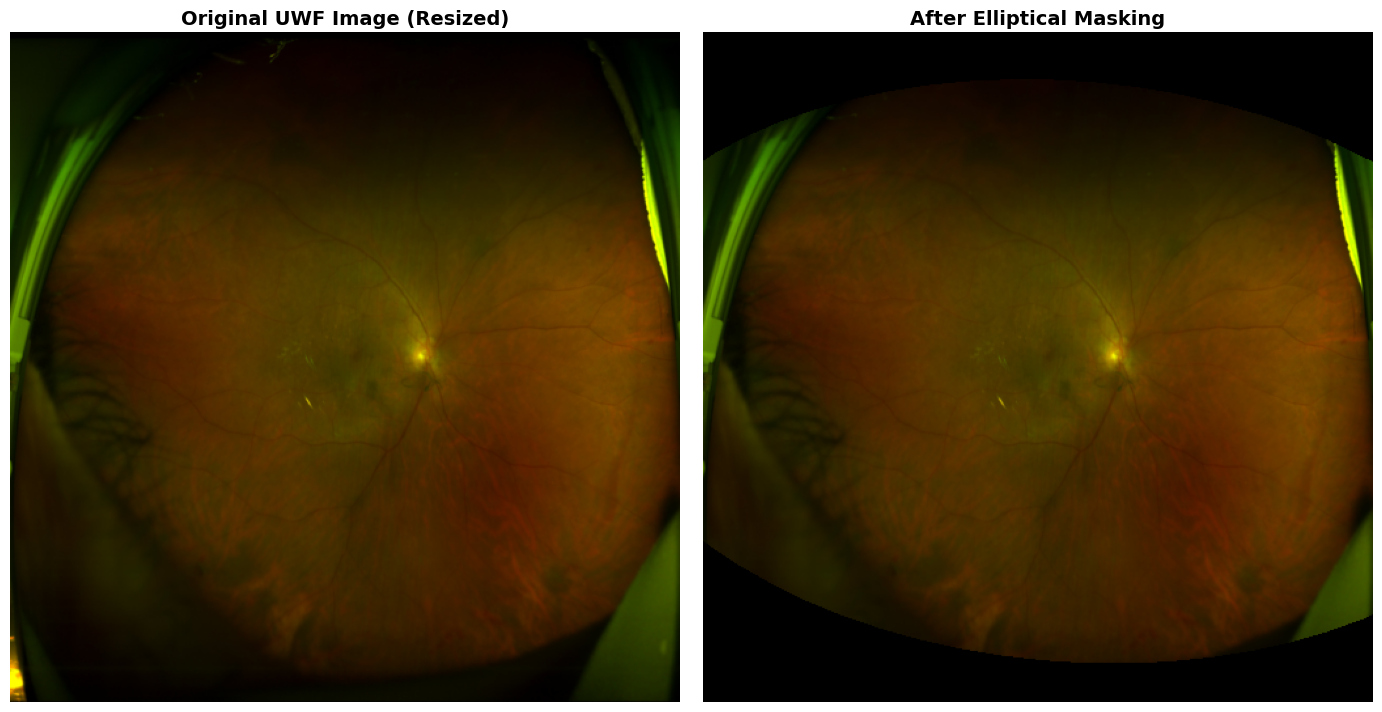

In [7]:
def visualize_masking(image_path):
    if not os.path.exists(image_path):
        print(f"[!] Image {image_path} not found. Please verify DATA_DIR.")
        return
        
    original_img = Image.open(image_path).convert('RGB')
    # FAST PRE-PROCESSING: Resize first before masking for visualization too
    original_img = original_img.resize((512, 512), Image.Resampling.BILINEAR)
    masked_img = apply_uwf_mask(original_img)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 7))
    axes[0].imshow(original_img)
    axes[0].set_title('Original UWF Image (Resized)', fontsize=14, fontweight='bold')
    axes[0].axis('off')
    
    axes[1].imshow(masked_img)
    axes[1].set_title('After Elliptical Masking', fontsize=14, fontweight='bold')
    axes[1].axis('off')
    plt.tight_layout()
    plt.show()

# Test visualization on the first training image in the UWF set
sample_image_path = os.path.join(DATA_DIR, 'MMRDR-UWF', 'img', 'tr000001.jpg')
visualize_masking(sample_image_path)

### Dataset Definition & DataLoaders

In [8]:
class UWF_Dataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df = df
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.img_dir, row['image'])
        
        if not os.path.exists(img_path):
            image = Image.new('RGB', (512, 512), (0, 0, 0))
        else:
            image = Image.open(img_path).convert('RGB')
            # OPTIMIZATION: Resize the massive high-res image BEFORE running heavy OpenCV masking!
            # This prevents the CPU from bottlenecking the GPU DataLoaders.
            image = image.resize((512, 512), Image.Resampling.BILINEAR)
            
        image = apply_uwf_mask(image)
        if self.transform: image = self.transform(image)
            
        grade = int(row['grade'])
        lesion_str = str(row['lesion']).strip().strip('[]')
        lesions = np.array([float(x.strip()) for x in lesion_str.split(',') if x.strip()], dtype=np.float32)
        if len(lesions) != 7: lesions = np.zeros(7, dtype=np.float32)
        
        # CRITICAL FIX: Ensure lesions are strictly binary (0 or 1). 
        # If dataset contains severity scores (e.g. 2, 3), thresholding it prevents sklearn multioutput errors.
        lesions = (lesions > 0).astype(np.float32)
            
        return image, grade, torch.tensor(lesions)

# --- ANTI-OVERFITTING: DATA AUGMENTATION ---
# Training gets flips and color jitter to prevent exact memorization
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.RandomRotation(degrees=10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Validation strictly evaluates the original images with zero augmentation
val_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Only load DataLoaders if the CSV actually exists (to prevent Kaggle errors if path is wrong)
csv_path = os.path.join(DATA_DIR, 'MMRDR-UWF', 'UWF.csv')
if os.path.exists(csv_path):
    df = pd.read_csv(csv_path)
    train_df, val_df = train_test_split(df, test_size=0.2, random_state=42)
    
    img_dir = os.path.join(DATA_DIR, 'MMRDR-UWF')
    
    # Apply distinct transforms
    train_loader = DataLoader(UWF_Dataset(train_df, img_dir, train_transform), batch_size=8, shuffle=True, num_workers=4, pin_memory=True)
    val_loader = DataLoader(UWF_Dataset(val_df, img_dir, val_transform), batch_size=8, shuffle=False, num_workers=4, pin_memory=True)
    print(f"DataLoaders initialized! Train samples: {len(train_df)}, Val samples: {len(val_df)}")
else:
    print("Dataset CSV not found. Ensure DATA_DIR is correct to initialize DataLoaders.")

DataLoaders initialized! Train samples: 8323, Val samples: 2081


## ⚖️ Asymmetric Cost-Sensitive Loss
Lesion Mapping:
`[0: MA, 1: HE, 2: IH, 3: VB/IRMA, 4: NV, 5: VH, 6: RD]`

We apply massive False Negative penalties ($\beta=0.95$) to indices 4 (NV), 5 (VH), and 6 (RD) as they define PDR.

In [9]:
# 4. ASYMMETRIC LOSS FUNCTION & DUMMY VALIDATION
class AsymmetricFocalLoss(nn.Module):
    def __init__(self, gamma=2.0):
        super().__init__()
        self.gamma = gamma
        # Beta weights per class: heavily weight positive class for PDR lesions
        # Indices: 0(MA), 1(HE), 2(IH), 3(VB), 4(NV), 5(VH), 6(RD)
        self.beta = torch.tensor([0.7, 0.7, 0.7, 0.8, 0.95, 0.95, 0.95]).to(device)

    def forward(self, logits, targets):
        # CRITICAL FIX: Use PyTorch's highly optimized BCEWithLogits to prevent NaN/Infinity gradients
        # This uses the Log-Sum-Exp trick internally, making it infinitely more stable than manual sigmoids
        bce_loss = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
        
        # Safely derive probabilities from the BCE loss
        pt = torch.exp(-bce_loss) 
        
        # Apply Asymmetric Beta weights
        # If target == 1, weight is beta. If target == 0, weight is (1-beta)
        alpha_t = targets * self.beta + (1 - targets) * (1 - self.beta)
        
        # Final Asymmetric Focal Loss
        focal_loss = alpha_t * (1 - pt)**self.gamma * bce_loss
        
        return focal_loss.mean()

# --- DUMMY DATA VALIDATION ---
print("Running Dummy Data Verification for Asymmetric Loss...")
dummy_loss_fn = AsymmetricFocalLoss()
dummy_target = torch.tensor([[0., 0., 0., 0., 1., 0., 0.]]).to(device) # NV (index 4) is present

# Case 1: False Negative (Predicts 0.1 for NV, misses the lesion)
fn_logits = torch.tensor([[0., 0., 0., 0., -2.0, 0., 0.]]).to(device) # sigmoid(-2) ~ 0.11

# Case 2: False Positive (Target 0, but predicts 0.9 for NV)
fp_target = torch.tensor([[0., 0., 0., 0., 0., 0., 0.]]).to(device)
fp_logits = torch.tensor([[0., 0., 0., 0., 2.0, 0., 0.]]).to(device)  # sigmoid(2) ~ 0.88

loss_fn_case = dummy_loss_fn(fn_logits, dummy_target)
loss_fp_case = dummy_loss_fn(fp_logits, fp_target)

print(f"Penalty for missing NV (False Negative): {loss_fn_case.item():.4f}")
print(f"Penalty for hallucinating NV (False Positive): {loss_fp_case.item():.4f}")
assert loss_fn_case > loss_fp_case, "Loss function is not asymmetric! FN penalty must be > FP penalty."
print("Success! False Negatives on PDR lesions are penalized far heavier than False Positives.\n")

Running Dummy Data Verification for Asymmetric Loss...
Penalty for missing NV (False Negative): 0.2536
Penalty for hallucinating NV (False Positive): 0.0415
Success! False Negatives on PDR lesions are penalized far heavier than False Positives.



## 🏗️ Model Architecture: `UWF_MultiScaleDRNet`
As requested, we implement the custom Multi-Scale DRNet from the findings document, which utilizes a ResNet stem, Feature Pyramid Network (FPN) for scale invariance, and Spatial Attention to identify tiny peripheral lesions on 200-degree UWF images.

In [10]:
# 5. ARCHITECTURE
class SpatialAttention(nn.Module):
    """Helps the network focus on tiny peripheral lesions across 200-degrees"""
    def __init__(self, kernel_size=7):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size=kernel_size, padding=kernel_size//2, bias=False)
        self.sigmoid = nn.Sigmoid()
    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        x_out = self.conv(torch.cat([avg_out, max_out], dim=1))
        return x * self.sigmoid(x_out)

class UWF_MultiScaleDRNet(nn.Module):
    def __init__(self):
        super().__init__()
        resnet = models.resnet50(weights='IMAGENET1K_V1') # Using ImageNet weights natively
        self.stem = nn.Sequential(resnet.conv1, resnet.bn1, resnet.relu, resnet.maxpool)
        self.layer1 = resnet.layer1
        self.layer2 = resnet.layer2
        self.layer3 = resnet.layer3
        self.layer4 = resnet.layer4
        
        self.lat_l4 = nn.Conv2d(2048, 512, kernel_size=1)
        self.lat_l3 = nn.Conv2d(1024, 512, kernel_size=1)
        self.lat_l2 = nn.Conv2d(512, 512, kernel_size=1)
        self.lat_l1 = nn.Conv2d(256, 512, kernel_size=1)
        
        self.attention = SpatialAttention()
        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))
        
        # ANTI-OVERFITTING: Adding a 50% Dropout layer before the classification heads
        self.dropout = nn.Dropout(p=0.5)
        
        self.head_a_lesion = nn.Linear(512, 7)  
        self.head_b_grade = nn.Linear(512, 5)   

    def forward(self, x):
        x = self.stem(x)
        l1 = self.layer1(x)
        l2 = self.layer2(l1)
        l3 = self.layer3(l2)
        l4 = self.layer4(l3)
        
        p4 = self.lat_l4(l4)
        p3 = self.lat_l3(l3) + F.interpolate(p4, size=l3.shape[-2:], mode='bilinear', align_corners=False)
        p2 = self.lat_l2(l2) + F.interpolate(p3, size=l2.shape[-2:], mode='bilinear', align_corners=False)
        p1 = self.lat_l1(l1) + F.interpolate(p2, size=l1.shape[-2:], mode='bilinear', align_corners=False)
        
        attended_features = self.attention(p1)
        pooled = self.global_pool(attended_features).flatten(1)
        
        # Pass pooled features through dropout to kill 50% of the neurons randomly
        pooled = self.dropout(pooled)
        
        lesion_logits = self.head_a_lesion(pooled)
        grade_logits = self.head_b_grade(pooled)
        return grade_logits, lesion_logits

model = UWF_MultiScaleDRNet().to(device)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 186MB/s] 


## 🚀 Training Loop
Here we implement the training loop that uses our `AsymmetricFocalLoss`. We also include Kaggle checkpointing logic to continuously save the best model to `/kaggle/working/`.

## 🎨 Post-Training Visualization: Grad-CAM Bounding Boxes
Since our dataset lacks explicit coordinate annotations (bounding boxes), we use **Weakly-Supervised Localization**. We extract Grad-CAM heatmaps from the `attention` layer and threshold them to draw accurate bounding boxes around the pathological regions.

In [11]:
# 6. MULTI-TASK TRAINING LOOP & METRICS
def calculate_metrics(grade_preds, grade_targets, lesion_probs, lesion_targets):
    # Grade metrics
    acc = accuracy_score(grade_targets, grade_preds)
    kappa = cohen_kappa_score(grade_targets, grade_preds, weights='quadratic')
    
    # Lesion metrics (Threshold at 0.5)
    lesion_preds = (np.array(lesion_probs) > 0.5).astype(int)
    
    # CRITICAL FIX: Ensure targets are strictly binarized (0 or 1) so sklearn doesn't error out
    lesion_targets_binary = (np.array(lesion_targets) > 0.5).astype(int) 
    
    f1 = f1_score(lesion_targets_binary, lesion_preds, average='macro', zero_division=0)
    
    # Calculate AUC (can fail if a batch has only 1 class)
    try:
        auc = roc_auc_score(lesion_targets_binary, lesion_probs, average='macro')
    except ValueError:
        auc = 0.0 # Fallback early in training
        
    return acc, kappa, f1, auc

def train_model(model, train_loader, val_loader, criterion_lesion, optimizer, scheduler, num_epochs=100, patience=15):
    best_loss = float('inf')
    epochs_no_improve = 0
    
    criterion_grade = nn.CrossEntropyLoss()
    scaler = torch.amp.GradScaler(device_type) if device_type == 'cuda' else None
    
    checkpoint_path = '/kaggle/working/checkpoint.pth'
    best_model_path = '/kaggle/working/best_model.pth'
    
    start_epoch, best_loss = load_checkpoint(checkpoint_path, model, optimizer, scheduler)
    
    for epoch in range(start_epoch, num_epochs):
        model.train()
        train_loss = 0.0
        
        train_grade_preds, train_grade_targets = [], []
        train_lesion_probs, train_lesion_targets = [], []
        
        print(f"\nEpoch {epoch+1}/{num_epochs} [LR: {optimizer.param_groups[0]['lr']:.2e}]")
        for images, grades, lesions in tqdm(train_loader, desc="Training"):
            images = images.to(device, non_blocking=True)
            grades = grades.to(device, non_blocking=True)
            lesions = lesions.to(device, non_blocking=True)
            
            optimizer.zero_grad()
            
            with torch.autocast(device_type=device_type):
                grade_logits, lesion_logits = model(images)
                loss_lesion = criterion_lesion(lesion_logits, lesions)
                loss_grade = criterion_grade(grade_logits, grades)
                loss = loss_lesion + loss_grade # Combined Multi-Task Loss
                
            if scaler is not None:
                scaler.scale(loss).backward()
                
                # CRITICAL: Gradient Clipping to prevent explosion and Model Collapse
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=2.0)
                
                scaler.step(optimizer)
                scaler.update()
            else:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=2.0)
                optimizer.step()
            
            train_loss += loss.item() * images.size(0)
            
            # Store for metrics
            train_grade_preds.extend(torch.argmax(grade_logits, dim=1).detach().cpu().numpy())
            train_grade_targets.extend(grades.cpu().numpy())
            train_lesion_probs.extend(torch.sigmoid(lesion_logits).detach().cpu().numpy())
            train_lesion_targets.extend(lesions.cpu().numpy())
            
        train_loss /= len(train_loader.dataset)
        t_acc, t_kappa, t_f1, t_auc = calculate_metrics(train_grade_preds, train_grade_targets, train_lesion_probs, train_lesion_targets)
        
        # Validation Phase
        model.eval()
        val_loss = 0.0
        val_grade_preds, val_grade_targets = [], []
        val_lesion_probs, val_lesion_targets = [], []
        
        with torch.no_grad():
            for images, grades, lesions in tqdm(val_loader, desc="Validation"):
                images = images.to(device, non_blocking=True)
                grades = grades.to(device, non_blocking=True)
                lesions = lesions.to(device, non_blocking=True)
                
                with torch.autocast(device_type=device_type):
                    grade_logits, lesion_logits = model(images)
                    loss_lesion = criterion_lesion(lesion_logits, lesions)
                    loss_grade = criterion_grade(grade_logits, grades)
                    loss = loss_lesion + loss_grade
                    
                val_loss += loss.item() * images.size(0)
                
                val_grade_preds.extend(torch.argmax(grade_logits, dim=1).detach().cpu().numpy())
                val_grade_targets.extend(grades.cpu().numpy())
                val_lesion_probs.extend(torch.sigmoid(lesion_logits).detach().cpu().numpy())
                val_lesion_targets.extend(lesions.cpu().numpy())
                
        val_loss /= len(val_loader.dataset)
        v_acc, v_kappa, v_f1, v_auc = calculate_metrics(val_grade_preds, val_grade_targets, val_lesion_probs, val_lesion_targets)
        
        print(f"\nTrain | Loss: {train_loss:.4f} | Grade Acc: {t_acc:.4f} | Grade Kappa: {t_kappa:.4f} | Lesion F1: {t_f1:.4f} | Lesion AUC: {t_auc:.4f}")
        print(f"Val   | Loss: {val_loss:.4f} | Grade Acc: {v_acc:.4f} | Grade Kappa: {v_kappa:.4f} | Lesion F1: {v_f1:.4f} | Lesion AUC: {v_auc:.4f}")
        
        # Step the scheduler based on validation loss
        scheduler.step(val_loss)
        
        # Checkpointing Logic (Saving best model based on Val Loss)
        is_best = val_loss < best_loss
        if is_best:
            best_loss = val_loss
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            
        # USER REQUESTED: Print Early Stopping Patience Counter
        print(f"Early Stopping Patience: {epochs_no_improve} / {patience}\n")
            
        save_checkpoint({
            'epoch': epoch + 1,
            'state_dict': model.state_dict(),
            'optimizer': optimizer.state_dict(),
            'scheduler': scheduler.state_dict(),
            'best_loss': best_loss,
        }, is_best, filename=checkpoint_path, best_filename=best_model_path)
        
        if epochs_no_improve >= patience:
            print(f"Early stopping triggered after {patience} epochs without improvement.")
            break

# Start training if DataLoaders were successfully initialized
if 'train_loader' in locals() and 'val_loader' in locals():
    print("Starting training procedure...")
    
    # ANTI-OVERFITTING: Increased Weight Decay (L2 Regularization) from 1e-4 to 1e-3
    optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-3)
    
    # Reduce Learning Rate if validation loss plateaus to prevent gradient explosion
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
    
    criterion_lesion = AsymmetricFocalLoss()
    train_model(model, train_loader, val_loader, criterion_lesion, optimizer, scheduler, num_epochs=100)
else:
    print("Skipping training as DataLoaders were not initialized.")


Starting training procedure...
[!] No checkpoint found at '/kaggle/working/checkpoint.pth', starting from scratch.

Epoch 1/100 [LR: 1.00e-04]


Validation: 100%|██████████| 261/261 [02:12<00:00,  1.97it/s]



Train | Loss: 1.0417 | Grade Acc: 0.5898 | Grade Kappa: 0.7723 | Lesion F1: 0.5216 | Lesion AUC: 0.8605
Val   | Loss: 0.7779 | Grade Acc: 0.6824 | Grade Kappa: 0.8719 | Lesion F1: 0.6424 | Lesion AUC: 0.9315
Early Stopping Patience: 0 / 15

[*] Saved new best model to /kaggle/working/best_model.pth

Epoch 2/100 [LR: 1.00e-04]


Validation: 100%|██████████| 261/261 [02:11<00:00,  1.99it/s]



Train | Loss: 0.8784 | Grade Acc: 0.6597 | Grade Kappa: 0.8484 | Lesion F1: 0.5855 | Lesion AUC: 0.8990
Val   | Loss: 0.7475 | Grade Acc: 0.7035 | Grade Kappa: 0.8853 | Lesion F1: 0.6202 | Lesion AUC: 0.9350
Early Stopping Patience: 0 / 15

[*] Saved new best model to /kaggle/working/best_model.pth

Epoch 3/100 [LR: 1.00e-04]


...


Train | Loss: 0.4795 | Grade Acc: 0.8300 | Grade Kappa: 0.9484 | Lesion F1: 0.7155 | Lesion AUC: 0.9473
Val   | Loss: 0.6926 | Grade Acc: 0.7674 | Grade Kappa: 0.9305 | Lesion F1: 0.7298 | Lesion AUC: 0.9485
Early Stopping Patience: 13 / 15


Epoch 30/100 [LR: 6.25e-06]


Validation: 100%|██████████| 261/261 [02:12<00:00,  1.98it/s]



Train | Loss: 0.4690 | Grade Acc: 0.8353 | Grade Kappa: 0.9517 | Lesion F1: 0.7173 | Lesion AUC: 0.9482
Val   | Loss: 0.7118 | Grade Acc: 0.7713 | Grade Kappa: 0.9297 | Lesion F1: 0.7294 | Lesion AUC: 0.9495
Early Stopping Patience: 14 / 15


Epoch 31/100 [LR: 6.25e-06]


Validation: 100%|██████████| 261/261 [02:14<00:00,  1.94it/s]



Train | Loss: 0.4698 | Grade Acc: 0.8334 | Grade Kappa: 0.9520 | Lesion F1: 0.7102 | Lesion AUC: 0.9475
Val   | Loss: 0.6764 | Grade Acc: 0.7684 | Grade Kappa: 0.9293 | Lesion F1: 0.7311 | Lesion AUC: 0.9490
Early Stopping Patience: 15 / 15

Early stopping triggered after 15 epochs without improvement.


Generating Post-Training Grad-CAM Visualizations...


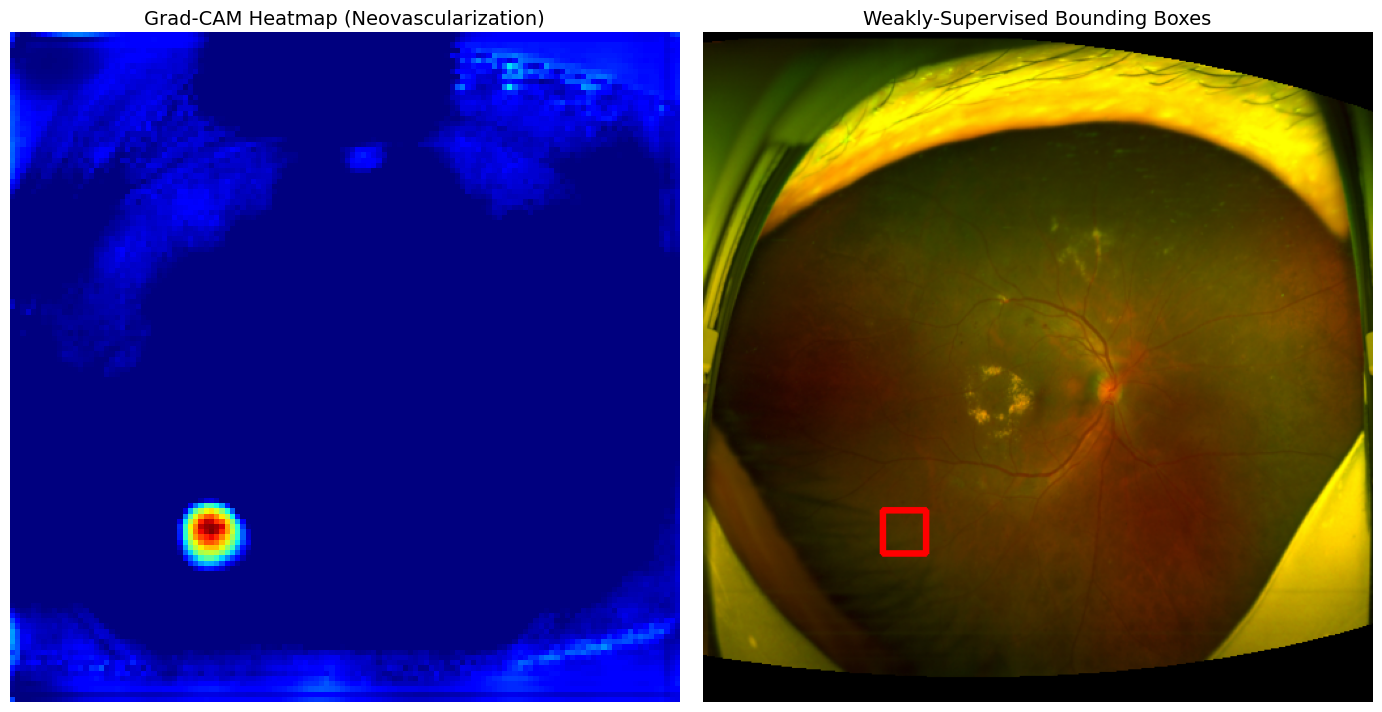

In [11]:
# 7. GRAD-CAM BOUNDING BOX EXTRACTION
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        target_layer.register_forward_hook(self.save_activation)
        target_layer.register_full_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def generate_heatmap(self, input_tensor, target_class, is_lesion=True):
        self.model.eval()
        self.model.zero_grad()
        grade_logits, lesion_logits = self.model(input_tensor)
        
        logits = lesion_logits if is_lesion else grade_logits
        score = logits[0, target_class]
        score.backward()
        
        weights = torch.mean(self.gradients, dim=(2, 3), keepdim=True)
        cam = torch.sum(weights * self.activations, dim=1).squeeze()
        cam = F.relu(cam)
        cam = cam - cam.min()
        cam = cam / (cam.max() + 1e-8)
        return cam.detach().cpu().numpy()

def generate_heatmap(image_numpy, heatmap, threshold_ratio=0.5):
    """Draws bounding boxes around the hottest regions in the Grad-CAM heatmap"""
    heatmap_resized = cv2.resize(heatmap, (image_numpy.shape[1], image_numpy.shape[0]))
    
    # Binary thresholding
    thresh_val = heatmap_resized.max() * threshold_ratio
    binary_map = np.uint8(heatmap_resized > thresh_val) * 255
    
    # Find contours and draw boxes
    contours, _ = cv2.findContours(binary_map, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    output_img = image_numpy.copy()
    for c in contours:
        if cv2.contourArea(c) > 50:  # ignore tiny noise
            x, y, w, h = cv2.boundingRect(c)
            cv2.rectangle(output_img, (x, y), (x+w, y+h), (255, 0, 0), 3) # Red Box
            
    return output_img

# Executing Grad-CAM visualization on a sample image post-training
if 'train_loader' in locals():
    print("Generating Post-Training Grad-CAM Visualizations...")
    # Grab a sample from validation loader
    sample_imgs, _, sample_lesions = next(iter(val_loader))
    img_tensor = sample_imgs[0:1].to(device)
    
    # Target class 4 represents Neovascularization (PDR Lesion)
    target_lesion_idx = 4 
    
    # Initialize GradCAM on the Spatial Attention layer
    cam_extractor = GradCAM(model, model.attention)
    heatmap = cam_extractor.generate_heatmap(img_tensor, target_class=target_lesion_idx)
    
    # Convert tensor back to numpy image for OpenCV
    img_numpy = img_tensor[0].cpu().numpy().transpose(1, 2, 0)
    # Denormalize
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img_numpy = std * img_numpy + mean
    img_numpy = np.clip(img_numpy, 0, 1) * 255
    img_numpy = img_numpy.astype(np.uint8)
    
    box_img = generate_heatmap(img_numpy, heatmap, threshold_ratio=0.6)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 7))
    axes[0].imshow(heatmap, cmap='jet')
    axes[0].set_title('Grad-CAM Heatmap (Neovascularization)', fontsize=14)
    axes[0].axis('off')
    
    axes[1].imshow(box_img)
    axes[1].set_title('Weakly-Supervised Bounding Boxes', fontsize=14)
    axes[1].axis('off')
    plt.tight_layout()
    plt.show()
